In [1]:
import os
import cv2
import kagglehub
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Dropout, SeparableConv2D, MaxPooling2D, BatchNormalization, Input

2026-03-22 17:51:33.802877: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774201893.976946      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774201894.026845      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774201894.425667      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774201894.425703      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774201894.425706      55 computation_placer.cc:177] computation placer alr

In [2]:
path = kagglehub.dataset_download("sabahesaraki/breast-ultrasound-images-dataset")
dataset_path = f"{path}/Dataset_BUSI_with_GT"
print("Path to dataset:", dataset_path)

Path to dataset: /kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT


In [3]:
IMG_SIZE = 224 #Fixing the size of each image as 224x224

data = []
labels = []
classes = ["normal", "benign", "malignant"]

for label in classes:
    path = os.path.join(dataset_path, label)
    for img in tqdm(os.listdir(path)):
        img_path = os.path.join(path, img)
        image = cv2.imread(img_path)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image / 255.0
        data.append(image)
        labels.append(label)

X = np.array(data)
y = np.array(labels)

print("Dataset shape:", X.shape)

100%|██████████| 421/421 [00:07<00:00, 60.01it/s]


Dataset shape: (1578, 224, 224, 3)


In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(np.unique(y_encoded))
print("Classes:", le.classes_)

Classes: ['benign' 'malignant' 'normal']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2, #80-20 split
    stratify=y_encoded,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1262, 224, 224, 3)
Test: (316, 224, 224, 3)


In [6]:
def build_ds_cnn(): 
    
    inputs = Input(shape=(224,224,3))

    x = SeparableConv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = SeparableConv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = SeparableConv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = SeparableConv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Flatten()(x)

    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [7]:
def evaluate_model(model, X_test, y_test):
    """Standard evaluation function, for all models, including baseline and other models after handling class imbalance. Calculates specific required metrics, ensuring proper depiction of the affects of class imbalance, without focusing on accuracy alone."""
    
    preds = model.predict(X_test)
    preds = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test, preds)
    precision = precision_score(y_test, preds, average='weighted')
    recall = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    report = classification_report(
        y_test,
        preds,
        target_names=classes,
        output_dict=True
    )

    return acc, precision, recall, f1, report

# **1. BASELINE MODEL**

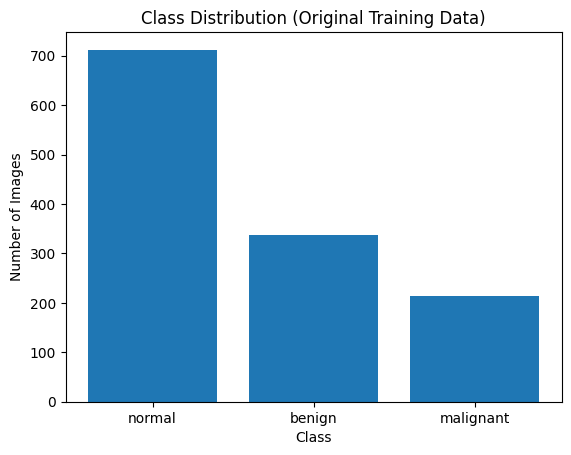

In [8]:
class_counts = np.bincount(y_train)

plt.figure()
plt.bar(classes, class_counts)
plt.title("Class Distribution (Original Training Data)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [9]:
baseline_model = build_ds_cnn()

history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_report = evaluate_model(baseline_model, X_test, y_test)

I0000 00:00:1774201943.881312      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/10


I0000 00:00:1774201950.265569     125 service.cc:152] XLA service 0x796e140058a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774201950.265606     125 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774201950.906658     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774201959.151564     125 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 426ms/step - accuracy: 0.5388 - loss: 2.4569 - val_accuracy: 0.1811 - val_loss: 1.2085
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7928 - loss: 0.6108 - val_accuracy: 0.1811 - val_loss: 1.4715
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8413 - loss: 0.4033 - val_accuracy: 0.1811 - val_loss: 1.7960
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8915 - loss: 0.2976 - val_accuracy: 0.1811 - val_loss: 2.2958
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9248 - loss: 0.2219 - val_accuracy: 0.1811 - val_loss: 2.8737
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9185 - loss: 0.2170 - val_accuracy: 0.1811 - val_loss: 2.6690
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9167 - loss: 0.2240 - val_accuracy: 0.1811 - val_loss: 3.0591
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9531 - loss: 0.1417 - val_accuracy: 0.1811 - val_loss: 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# **2. APPLYING CLASS WEIGHTS**

In [10]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights) #These are class weights computed using the inbuilt function, based on the representation of each class in the whole dataset

Class Weights: {0: np.float64(0.5908239700374532), 1: np.float64(1.248269040553907), 2: np.float64(1.9749608763693272)}


In [11]:
weighted_model = build_ds_cnn()

history = weighted_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)

weighted_acc, weighted_prec, weighted_rec, weighted_f1, weighted_report = evaluate_model(weighted_model, X_test, y_test)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step - accuracy: 0.4852 - loss: 2.7665 - val_accuracy: 0.1811 - val_loss: 1.2685
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6790 - loss: 0.8472 - val_accuracy: 0.1811 - val_loss: 1.4627
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7626 - loss: 0.5376 - val_accuracy: 0.1811 - val_loss: 2.1141
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8416 - loss: 0.3833 - val_accuracy: 0.1811 - val_loss: 2.6228
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8721 - loss: 0.2986 - val_accuracy: 0.1811 - val_loss: 2.9707
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8616 - loss: 0.3148 - val_accuracy: 0.1811 - val_loss: 3.9708
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8979 - loss: 0.2259 - val_accuracy: 0.1811 - val_loss: 4.8890
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9194 - loss: 0.2042 - val_accuracy: 0.1811 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# **3. DATA AUGMENTATION**

In [12]:
#Application of basic data augmentation limited to rotation, horizontal and vertical translations, zooming, and lastly, flipping
augmentor = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [13]:
X_aug = []
y_aug = []

class_counts = np.bincount(y_train)
max_count = np.max(class_counts)

for class_id in range(num_classes):
    imgs = X_train[y_train == class_id]
    needed = max_count - len(imgs)
    X_aug.extend(imgs)
    y_aug.extend([class_id]*len(imgs)) #Adding the augemented data to the original data

    if needed > 0:
        gen = augmentor.flow(imgs, batch_size=1)
        for _ in range(needed):
            img = next(gen)[0]
            X_aug.append(img)
            y_aug.append(class_id)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

print("Original dataset:", X.shape)
print("Augmented dataset:", X_aug.shape)

Original dataset: (1578, 224, 224, 3)
Augmented dataset: (2136, 224, 224, 3)


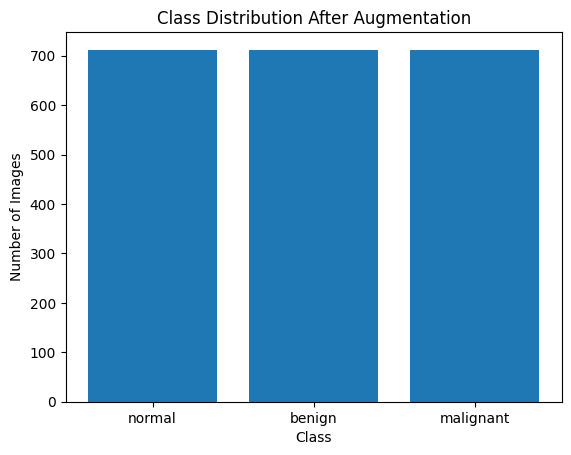

In [14]:
aug_counts = np.bincount(y_aug)

plt.figure()
plt.bar(classes, aug_counts)
plt.title("Class Distribution After Augmentation")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [15]:
aug_model = build_ds_cnn()

history = aug_model.fit(
    X_aug, y_aug,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

aug_acc, aug_prec, aug_rec, aug_f1, aug_report = evaluate_model(aug_model, X_test, y_test)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 23s 249ms/step - accuracy: 0.5392 - loss: 2.3933 - val_accuracy: 1.0000 - val_loss: 0.4539
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7229 - loss: 0.7386 - val_accuracy: 1.0000 - val_loss: 0.0999
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7804 - loss: 0.5550 - val_accuracy: 1.0000 - val_loss: 0.0182
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8253 - loss: 0.4409 - val_accuracy: 1.0000 - val_loss: 0.0030
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8353 - loss: 0.3913 - val_accuracy: 1.0000 - val_loss: 1.5377e-05
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8740 - loss: 0.3161 - val_accuracy: 1.0000 - val_loss: 1.6834e-06
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8925 - loss: 0.2933 - val_accuracy: 1.0000 - val_loss: 2.8911e-07
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9096 - loss: 0.2354 - val_accura

# **4. SMOTE**

In [16]:
X_train_flat = X_train.reshape(len(X_train), -1)
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_flat, y_train)
X_smote = X_smote.reshape(-1,224,224,3)

print("Original dataset:", X.shape)
print("SMOTE dataset:", X_smote.shape)

Original dataset: (1578, 224, 224, 3)
SMOTE dataset: (2136, 224, 224, 3)


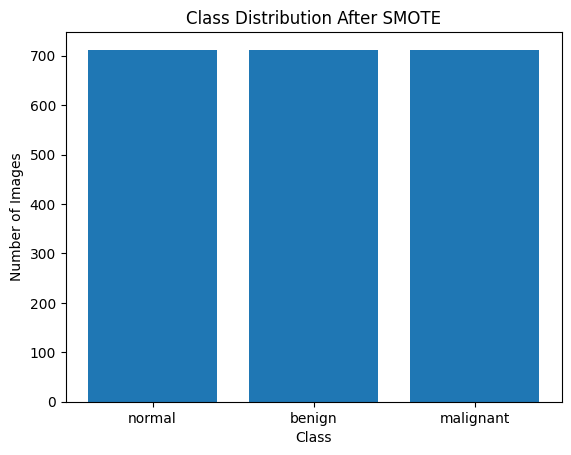

In [17]:
smote_counts = np.bincount(y_smote)

plt.figure()
plt.bar(classes, smote_counts)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [18]:
smote_model = build_ds_cnn()

history = smote_model.fit(
    X_smote, y_smote,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

smote_acc, smote_prec, smote_rec, smote_f1, smote_report = evaluate_model(smote_model, X_test, y_test)

Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.5509 - loss: 2.1690 - val_accuracy: 1.0000 - val_loss: 0.2830
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7938 - loss: 0.5771 - val_accuracy: 1.0000 - val_loss: 0.0542
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8736 - loss: 0.3589 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8928 - loss: 0.2745 - val_accuracy: 1.0000 - val_loss: 8.5628e-04
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9250 - loss: 0.2047 - val_accuracy: 1.0000 - val_loss: 4.2558e-05
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.9206 - loss: 0.1975 - val_accuracy: 1.0000 - val_loss: 6.4323e-06
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9530 - loss: 0.1343 - val_accuracy: 1.0000 - val_loss: 1.5068e-06
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9619 - loss: 0.1122 - val_ac

# **5. FOCAL LOSS**

In [19]:
def focal_loss(alpha=0.25, gamma=2.0):
    
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=num_classes)
        ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal = alpha * tf.pow((1 - p_t), gamma) * ce
        return tf.reduce_mean(focal)
        
    return loss

focal_model = build_ds_cnn()

focal_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(alpha=0.25, gamma=2),
    metrics=['accuracy']
)

history = focal_model.fit(
    X_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32
)

focal_acc, focal_prec, focal_rec, focal_f1, focal_report = evaluate_model(focal_model, X_test, y_test)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 17s 267ms/step - accuracy: 0.5229 - loss: 0.5665 - val_accuracy: 0.1811 - val_loss: 0.1748
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7185 - loss: 0.1108 - val_accuracy: 0.1811 - val_loss: 0.2578
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8248 - loss: 0.0658 - val_accuracy: 0.1811 - val_loss: 0.4752
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8411 - loss: 0.0439 - val_accuracy: 0.1811 - val_loss: 0.5784
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8564 - loss: 0.0374 - val_accuracy: 0.1811 - val_loss: 0.6858
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8821 - loss: 0.0311 - val_accuracy: 0.1811 - val_loss: 0.9899
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9138 - loss: 0.0252 - val_accuracy: 0.1811 - val_loss: 1.1953
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9132 - loss: 0.0178 - val_accuracy: 0.1811 -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

# **RESULTS**

In [20]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Class Weights",
        "Augmentation",
        "SMOTE",
        "Focal Loss"
    ],
    "Accuracy": [
        baseline_acc,
        weighted_acc,
        aug_acc,
        smote_acc,
        focal_acc
    ],
    "Precision": [
        baseline_prec,
        weighted_prec,
        aug_prec,
        smote_prec,
        focal_prec
    ],
    "Recall": [
        baseline_rec,
        weighted_rec,
        aug_rec,
        smote_rec,
        focal_rec
    ],
    "F1 Score": [
        baseline_f1,
        weighted_f1,
        aug_f1,
        smote_f1,
        focal_f1
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.167722,0.028131,0.167722,0.048180
1,Class Weights,0.167722,0.028131,0.167722,0.048180
2,Augmentation,0.452532,0.585861,0.452532,0.421174
3,SMOTE,0.509494,0.645745,0.509494,0.514279
4,Focal Loss,0.167722,0.028131,0.167722,0.048180


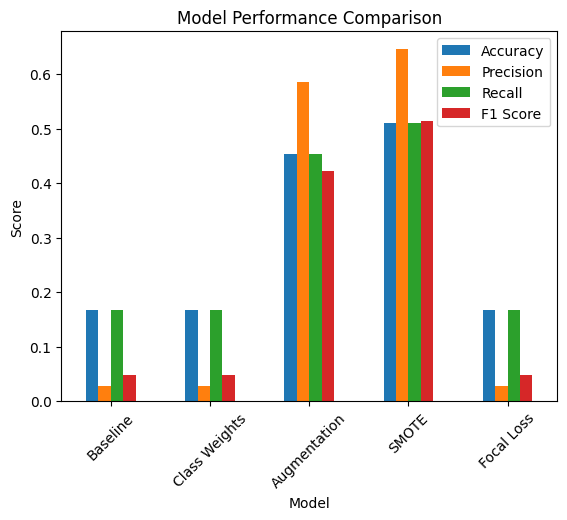

In [21]:
metrics = results.set_index("Model")

metrics.plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

In [22]:
rows = []

models_reports = {
    "Baseline": (baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_report),
    "Class Weights": (weighted_acc, weighted_prec, weighted_rec, weighted_f1, weighted_report),
    "Augmentation": (aug_acc, aug_prec, aug_rec, aug_f1, aug_report),
    "SMOTE": (smote_acc, smote_prec, smote_rec, smote_f1, smote_report),
    "Focal Loss": (focal_acc, focal_prec, focal_rec, focal_f1, focal_report)
}

for model_name, (acc, prec, rec, f1, report) in models_reports.items():
    for cls in classes:
        rows.append({
            "Model": model_name,
            "Accuracy": acc,
            "Overall Precision": prec,
            "Overall Recall": rec,
            "Overall F1": f1,
            "Class": cls,
            "Class Precision": report[cls]["precision"],
            "Class Recall": report[cls]["recall"],
            "Class F1": report[cls]["f1-score"]
        })

final_results = pd.DataFrame(rows)
display(final_results)

,Model,Accuracy,Overall Precision,Overall Recall,Overall F1,Class,Class Precision,Class Recall,Class F1
0,Baseline,0.167722,0.028131,0.167722,0.048180,normal,0.000000,0.000000,0.000000
1,Baseline,0.167722,0.028131,0.167722,0.048180,benign,0.000000,0.000000,0.000000
2,Baseline,0.167722,0.028131,0.167722,0.048180,malignant,0.167722,1.000000,0.287263
3,Class Weights,0.167722,0.028131,0.167722,0.048180,normal,0.000000,0.000000,0.000000
4,Class Weights,0.167722,0.028131,0.167722,0.048180,benign,0.000000,0.000000,0.000000
5,Class Weights,0.167722,0.028131,0.167722,0.048180,malignant,0.167722,1.000000,0.287263
6,Augmentation,0.452532,0.585861,0.452532,0.421174,normal,0.732143,0.229050,0.348936
7,Augmentation,0.452532,0.585861,0.452532,0.421174,benign,0.427632,0.773810,0.550847
8,Augmentation,0.452532,0.585861,0.452532,0.421174,malignant,0.342593,0.698113,0.459627
9,SMOTE,0.509494,0.645745,0.509494,0.514279,normal,0.709091,0.435754,0.539792


In [23]:
malignant_recall = {
    "Baseline": baseline_report["malignant"]["recall"],
    "Class Weights": weighted_report["malignant"]["recall"],
    "Augmentation": aug_report["malignant"]["recall"],
    "SMOTE": smote_report["malignant"]["recall"],
    "Focal Loss": focal_report["malignant"]["recall"]
}

pd.DataFrame.from_dict(malignant_recall, orient="index", columns=["Malignant Recall"])

,Malignant Recall
Baseline,1.000000
Class Weights,1.000000
Augmentation,0.698113
SMOTE,1.000000
Focal Loss,1.000000


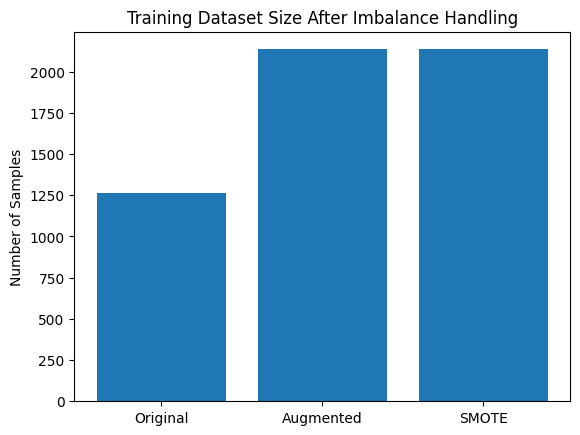

In [24]:
#Dataset size comparision

sizes = {
    "Original": len(X_train),
    "Augmented": len(X_aug),
    "SMOTE": len(X_smote)
}

plt.figure()
plt.bar(sizes.keys(), sizes.values())
plt.title("Training Dataset Size After Imbalance Handling")
plt.ylabel("Number of Samples")
plt.show()